### Context:
#### Social Media Platform: YouTube
#### Company: Jamaica Gleaner
#### Type of Company: Multi-media organization (newspaper, radio etc.)
#### No. of videos analyzed: 3-4
#### YouTube API Reference Docs: 
- https://developers.google.com/youtube/v3/determine_quota_cost
- https://developers.google.com/youtube/v3/guides/implementation/pagination
#### Objectives:
- To categorize YouTube video titles by news category
- To measure engagement (likes) per news category via mean, median, count and distribution
- To measure engagement (likes) trends over time
- To assess relationship between likes, comments and number of views 
- To assess relationship between hashtag use in video titles and engagement (likes)
- To assess relationship between video length and engagement (likes)
- To perform sentiment analysis on video titles
- To perform topic modeling (LDA) on video titles
- To display top-performing videos

### Preliminary Steps
#### Purpose: Load necessary libraries, read API key, retrieve channel ID and define categories & keywords

In [1]:
# Import Libraries
import requests # for API request
import pandas as pd # for dataframes
import matplotlib.pyplot as plt # for visuals
import seaborn as sns # for visuals
from collections import Counter # for counting hashable objects i.e objects' values remain constant over their lifetime
import numpy as np # for numerical operations
import re # for identifying patterns in text (emojis, symbols): Regular Expression library

# NLP
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [2]:
# Read API Key from file
with open("API_Key", "r") as file:
    API_KEY = file.read().strip()

print("API Key Loaded:", API_KEY[:5], "...")  # partial display for safety

API Key Loaded: AIzaS ...


In [3]:
# Get Channel ID Using Handle
handle = "@JamaicaGleaner"

url = "https://www.googleapis.com/youtube/v3/channels"

params = {
    "part": "id",
    "forHandle": handle,
    "key": API_KEY
}

response = requests.get(url, params=params).json()

channel_id = response['items'][0]['id']
print("Channel ID:", channel_id)

Channel ID: UCV2EtSzQ09E656SR4zcRvSA


In [4]:
# Define Categories and Keywords
categories = {
    "latest news": ["breaking", "update", "developing", "incident", "report", "police", "statement", "investigation", "emergency", "alert", "victim", "scene"],
    "all news": ["headline", "coverage", "reporting", "journalism", "editorial", "update", "feature", "newsroom", "brief", "bulletin", "article", "story"],
    "shipping news": ["dockyard", "cargo", "port", "logistics", "freight", "vessel", "container", "maritime", "customs", "import", "shipment", "harbour"],
    "world news": ["diplomacy", "geopolitics", "conflict", "sanctions", "summit", "foreign policy", "warfare",  "ceasefire", "alliance", "treaty", "migration", "refugees"],
    "sports": ["match", "goal", "scoreline", "player", "coach", "league", "tournament", "championship", "referee", "training", "fitness", "injury"],
    "business": ["enterprise", "revenue", "profit", "investment", "market trends", "stock exchange", "entrepreneur", "commerce", "trade", "industry", "inflation", "banking"],
    "entertainment": ["celebrity", "film", "music", "concert", "festival", "performance", "production", "director", "actor", "actress", "drama", "comedy"],
    "commentary": ["opinion", "editorial", "analysis", "perspective", "argument", "critique", "debate", "viewpoint", "insight", "reflection", "assessment", "reflection"],
    "letters": ["dear editor", "submission", "correspondence", "reader", "feedback", "response", "opinion", "complaint", "concern", "suggestion", "appreciation", "letter writer"],
    "in focus": ["feature", "spotlight", "investigation", "deep dive", "special report", "analysis", "background", "context", "profile", "coverage", "case study", "insight"],
    "art & leisure": ["artwork", "gallery", "exhibition", "museum", "culture", "painting", "sculpture", "design", "creative", "photography", "craft", "heritage"],
    "food": ["recipe", "cuisine", "dish", "cooking", "ingredient", "kitchen", "chef", "restaurant", "menu", "flavour", "taste", "dining"],
    "health": ["wellness", "fitness", "medical", "doctor", "treatment", "disease", "prevention", "nutrition", "exercise", "mental health", "therapy", "patient"],
    "auto": ["automobile", "engine", "vehicle", "fuel", "electric vehicle", "hybrid", "transmission", "brake system", "tire", "maintenance", "repair", "dealership"]
}

### Get Videos from Channel (Using Pagination)
#### Purpose: To retrieve recent videos from the YouTube channel via the API

In [5]:
# Variables for pagination
videos_data = [] # empty list to store videos
next_page_token = None # keeps track of next page

while True: # begins pagination loop
    url = "https://www.googleapis.com/youtube/v3/search" # defines API URL. Uses search endpoint to find videos, channels or playlist

    # set request parameters
    params = { 
        "part": "snippet", # return video snippet
        "channelId": channel_id, # search within specified channel
        "maxResults": 50, # no. of videos to return
        "order": "date", # retrieve most recent videos first
        "type": "video", # return video content
        "pageToken": next_page_token, # which page of results to retrieve next 
        "key": API_KEY # authenticate request via API key
    }

    response = requests.get(url, params=params).json() # sends API request. Returns in JSON format

    # extracts videos
    for item in response.get("items", []): # iterates through results from API request
            videos_data.append({
                "video_id": item["id"]["videoId"],
                "title": item["snippet"]["title"],
                "published_at": item["snippet"]["publishedAt"]
            }) # appends video data to video_data list

    next_page_token = response.get("nextPageToken") # checks for another page of results; retrieves next page token

    # breaks loop if no more pages exist
    if not next_page_token:
        break

print("Total Videos Retrieved:", len(videos_data))
print(videos_data[:10])

Total Videos Retrieved: 4
[{'video_id': 'iU9fpxFr9S8', 'title': 'THE GLEANER MINUTE: JFJ calls for body-worn cameras again | No legal deadline for tabling IC Reports', 'published_at': '2026-05-19T23:15:54Z'}, {'video_id': 'IF0rzHpx7w4', 'title': 'THE GLEANER MINUTE: Outrage Grows Over St James Police Killing, INDECOM Seeks Video Evidence', 'published_at': '2026-05-18T21:34:47Z'}, {'video_id': 'YJBP97gOhqo', 'title': 'JAMAICA NOW: More than $1b Hurricane donations unspent | Ja’s identity questioned | 13-y-o in coma', 'published_at': '2026-05-17T23:20:34Z'}, {'video_id': 'vO-58WtH5HA', 'title': 'THE GLEANER MINUTE: Flippa Mafia was under surveillance | Stabbed 13-y-o in coma | Dennis Lalor dies', 'published_at': '2026-05-14T22:44:43Z'}]


### Exploratory Data Analysis (EDA)

In [6]:
# Convert to Dataframe
df = pd.DataFrame(videos_data)
df.head()

,video_id,title,published_at
0,iU9fpxFr9S8,THE GLEANER MINUTE: JFJ calls for body-worn ca...,2026-05-19T23:15:54Z
1,IF0rzHpx7w4,THE GLEANER MINUTE: Outrage Grows Over St Jame...,2026-05-18T21:34:47Z
2,YJBP97gOhqo,JAMAICA NOW: More than $1b Hurricane donations...,2026-05-17T23:20:34Z
3,vO-58WtH5HA,THE GLEANER MINUTE: Flippa Mafia was under sur...,2026-05-14T22:44:43Z


In [7]:
# Displays information about the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   video_id      4 non-null      object
 1   title         4 non-null      object
 2   published_at  4 non-null      object
dtypes: object(3)
memory usage: 228.0+ bytes


In [8]:
# Displays description of data in dataframe
df.describe() 

,video_id,title,published_at
count,4,4,4
unique,4,4,4
top,iU9fpxFr9S8,THE GLEANER MINUTE: JFJ calls for body-worn ca...,2026-05-19T23:15:54Z
freq,1,1,1


### Categorize Videos
#### Purpose: To categorize video titles based on keywords

In [9]:
# Define Categorization Function
def categorize_title(title):
    title = title.lower() # Convert title to lowercase
    scores = {} # Store keyword match scores
    
    for category, keywords in categories.items(): # Count keyword matches for each category
        scores[category] = sum(
            title.count(word)
            for word in keywords
        )
        
    return max(scores, key=scores.get) # Return category with highest score

In [10]:
# Applies function and stores to "category" column
df["category"] = df["title"].apply(categorize_title) 

### Retrieve Video Stats
#### Purpose: To gather & store statistics of each video stored in the dataframe

In [11]:
stats_data = [] # empty list to store statistics

for video_id in df["video_id"]: # iterates through each video id in dataframe

    url = "https://www.googleapis.com/youtube/v3/videos" # uses API URL. Uses videos endpoint to find videos

    # sets parameters
    params = {
        "part": "statistics,contentDetails",
        "id": video_id,
        "key": API_KEY
    }

    response = requests.get(url, params=params).json() # sends API request. Returns in JSON format

    items = response.get("items", []) # stores results from API request

    if len(items) > 0: # if no. of results in "items" is > 0

        stats = items[0]["statistics"] # stores statistics value from 1st dictionary in items 
        details = items[0]["contentDetails"] # stores contentDetails value from 1st dictionary in items

        stats_data.append({
            "video_id": video_id,
            "likes": int(stats.get("likeCount", 0)),
            "views": int(stats.get("viewCount", 0)),
            "comments": int(stats.get("commentCount", 0)),
            "duration": details.get("duration", "")
        }) # appends statistics data to stats_data list

stats_df = pd.DataFrame(stats_data) # converts & stores stats_data as dataframe

df = df.merge(stats_df, on="video_id") # updates df using stats_df content

### Category Popularity Metrics
#### Purpose: To analyze video popularity based on likes attained 

In [12]:
# Groups videos by category, calculates metrics on no. of likes & stores to category_stats
category_stats = df.groupby("category")["likes"].agg(["mean", "median", "count"]) 
print(category_stats)

             mean  median  count
category                        
latest news  63.0    77.0      4


##### Interpretation: 
###### All 4 videos belong to the "latest news" category considering words in their titles matched keywords defined for that category. Moreover, the number of likes per video is approximately 77, considering the median which is less sensitive to outliers.

##### Business Impact:
###### Reserved for larger dataset.

### Boxplot of Category Distribution
#### Purpose: To display a boxplot of engagement (likes) variation per category

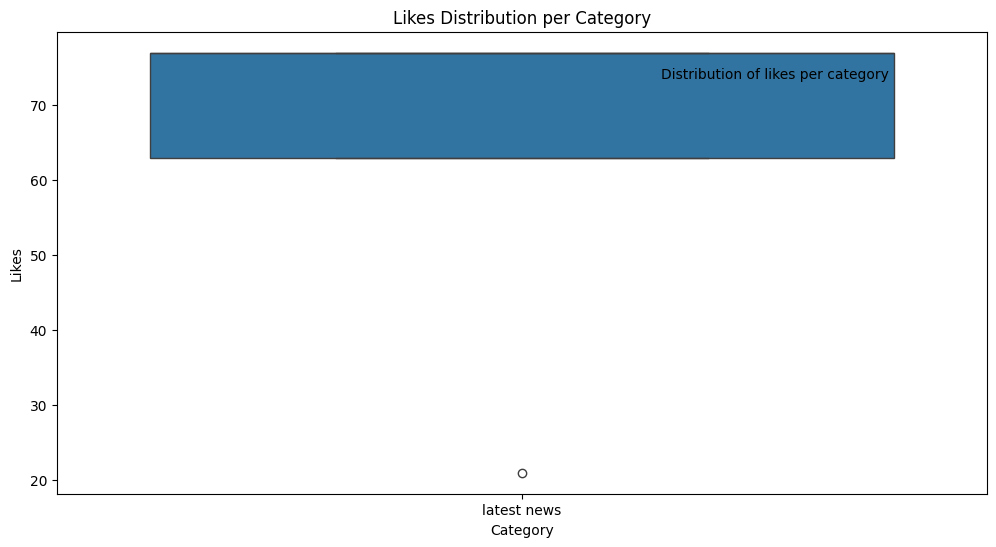

In [13]:
plt.figure(figsize=(12,6))
sns.boxplot(x="category", y="likes", data=df)
plt.xticks(rotation=0)
plt.title("Likes Distribution per Category")
plt.xlabel("Category")
plt.ylabel("Likes")
plt.annotate(
    "Distribution of likes per category",
    xy=(0.7, 1.02),
    xytext=(0.65, 0.9),
    xycoords="axes fraction",
)
plt.show()

##### Interpretation:
###### For the "latest news" category, the minimum number of likes was 73 while the maximum was 75, as depicted by the lowest and highest 
###### horizontal bars of the boxplot, respectively. Furthermore, twenty-five percent (25%) of the videos had below 74 likes, fifty percent (50%) had 
###### below 75 likes and seventy-five percent (75%) had below 76 likes as defined by the quartiles. However, fifty percent (50%) of the data has between 74 and 76 likes. 

##### Business Impact:
###### Reserved for larger dataset.

### Histogram of Category Distribution
#### Purpose: To display the likes distribution per category

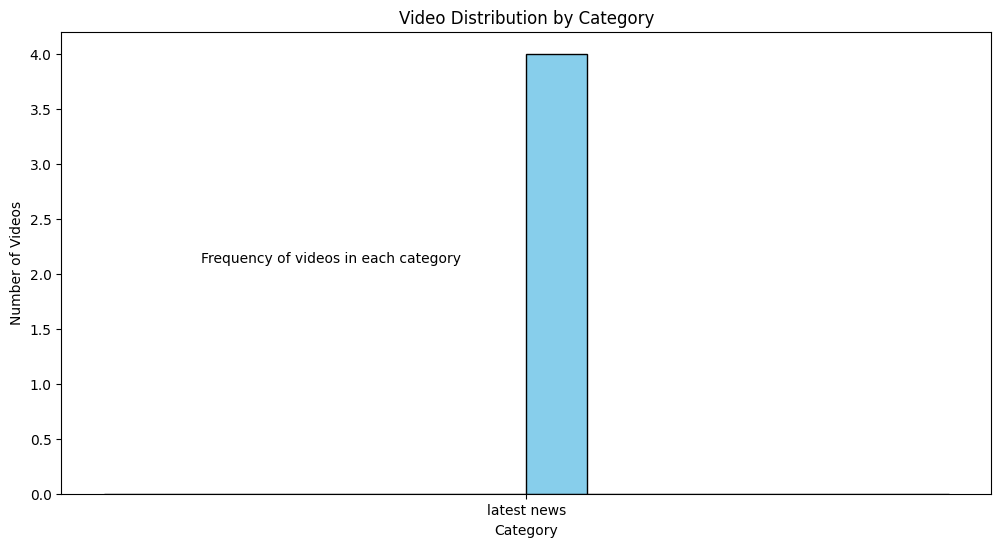

In [14]:
plt.figure(figsize=(12,6))
plt.hist(df["category"], bins=14, color='skyblue', edgecolor='black') # display histogram
plt.title("Video Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Number of Videos")
plt.xticks(rotation=0)
plt.annotate(
    "Frequency of videos in each category",
    xy=(0.15, 0.5),
    xycoords='axes fraction'
)
plt.show()

##### Interpretation: 
###### "Latest news" is the only category represented and has a count of 4 videos.

##### Business Impact:
###### Reserved for larger dataset.

### Engagement Over Time
#### Purpose: To display a line graph of engagement (likes) on videos over time 

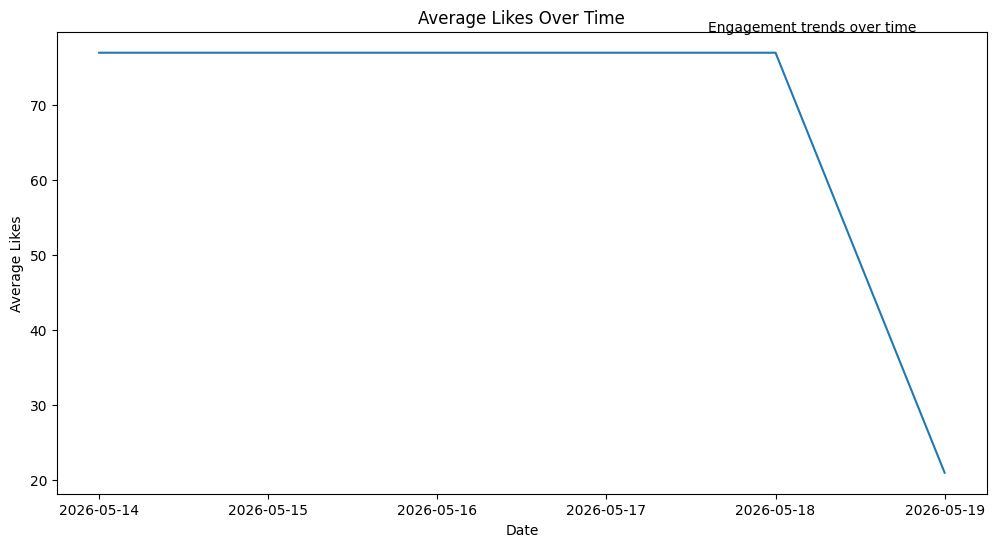

In [15]:
df["published_at"] = pd.to_datetime(df["published_at"]) # converts "published_at" column to date/time format

daily_engagement = df.groupby(df["published_at"].dt.date)["likes"].mean() # group videos by dates only & calculates mean no. of likes
plt.figure(figsize=(12,6))
daily_engagement.plot() # line plot of engagement
plt.title("Average Likes Over Time")
plt.xlabel("Date")
plt.ylabel("Average Likes")
plt.annotate(
    "Engagement trends over time",
    xy=(0.7, 1),
    xycoords='axes fraction'
)
plt.show()

##### Interpretation:
###### Over May 14, 2026 to May 18, 2026, the number of likes remained constant at an average of 77; however, fell dramatically to 0 average likes by May 19, 2026. The poor number of likes by May 19, 2026 could be attributed to the recency of videos wherein YouTube users had not yet engaged with the content.

##### Business Impact:
###### Reserved for larger dataset.

### Comments vs Engagement
#### Purpose: To see relationship between comments and likes (More comments = more likes?)

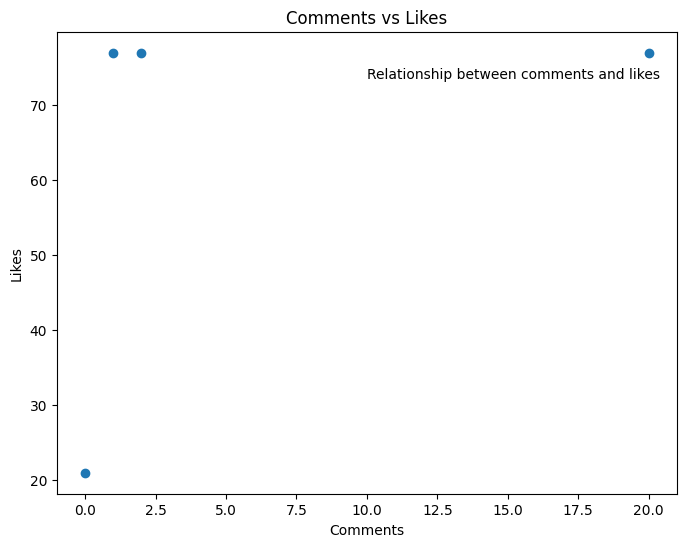

In [16]:
# Scatterplot of no. of likes & comments
plt.figure(figsize=(8,6))
plt.scatter(df["comments"], df["likes"])
plt.xlabel("Comments")
plt.ylabel("Likes")
plt.title("Comments vs Likes")
plt.annotate(
    "Relationship between comments and likes",
    xy=(0.5, 0.9),
    xycoords='axes fraction'
)
plt.show()

##### Interpretation:
###### As the points are scattered with no discernable pattern (direction or clustering), no relationship exists between the number of comments and 
###### number of likes a video receives. In other words, an increase/decrease in the number of comments on a video does not directly influence the 
###### number of likes it receives.

##### Business Impact:
###### Reserved for larger dataset.

### Views vs Engagement
#### Purpose: To see relationship between views and likes (More views = more likes?)

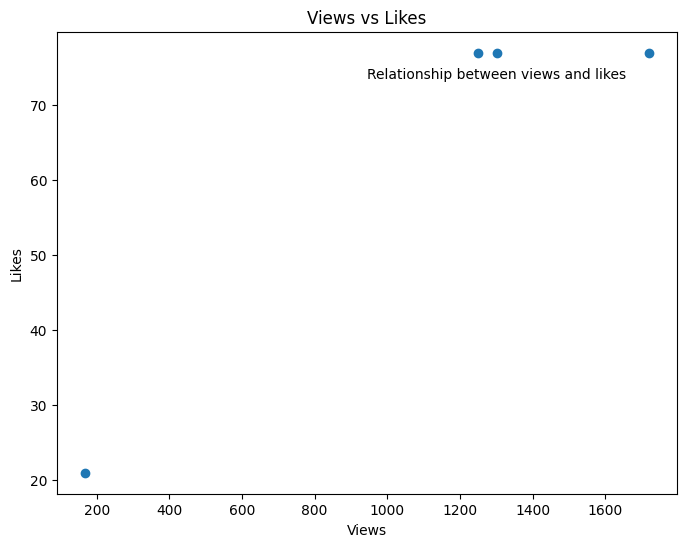

In [17]:
# Scatterplot of no. of likes & comments
plt.figure(figsize=(8,6))
plt.scatter(df["views"], df["likes"])
plt.xlabel("Views")
plt.ylabel("Likes")
plt.title("Views vs Likes")
plt.annotate(
    "Relationship between views and likes",
    xy=(0.5, 0.9),
    xycoords='axes fraction'
)
plt.show()

##### Interpretation:
###### As the points are scattered with no discernable pattern (direction or clustering), no relationship exists between the number of views and 
###### number of likes a video receives. In other words, an increase/decrease in the number of views for a video does not directly influence the 
###### number of likes it receives.

##### Business Impact:
###### Reserved for larger dataset.

### Likes vs Comments vs Views
#### Purpose: To see relationship between likes, comments and views (More comments = More views = More likes?)

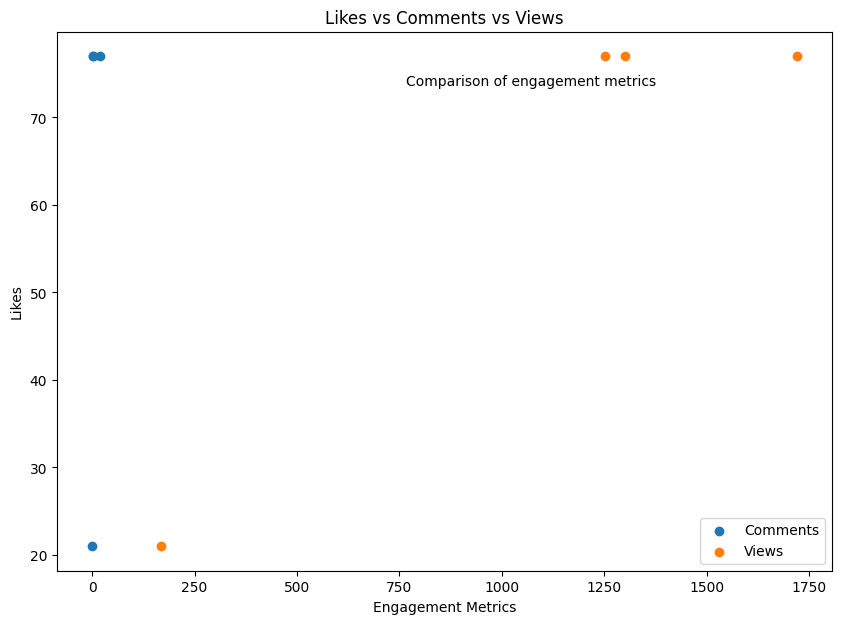

In [18]:
# Create figure
plt.figure(figsize=(10,7))

# Likes vs Comments
plt.scatter(df["comments"], df["likes"], label="Comments")

# Likes vs Views
plt.scatter(df["views"], df["likes"], label="Views")

# Title
plt.title("Likes vs Comments vs Views")

# Axis labels
plt.xlabel("Engagement Metrics")
plt.ylabel("Likes")

# Legend
plt.legend()

# Annotation
plt.annotate(
    "Comparison of engagement metrics",
    xy=(0.45, 0.9),
    xycoords='axes fraction'
)

# Display chart
plt.show()

##### Interpretation:
###### As the points are scattered with no discernable pattern (direction or clustering), no relationship exists between the number of comments and views and number of likes a video receives. In other words, an increase/decrease in the number of comments and views for a video does not directly influence the number of likes it receives.

##### Business Impact:
###### Reserved for larger dataset.

### All Caps Words vs Engagement
#### Purpose: To see relationship between all caps words in video title and likes received (Includes all caps words = more likes?)

In [19]:
# Function to count all caps words
def count_all_caps_words(title):

    # Split title into words
    words = title.split()

    # Count words that are fully uppercase
    return sum(
        1 for word in words
        if word.isupper()
    )

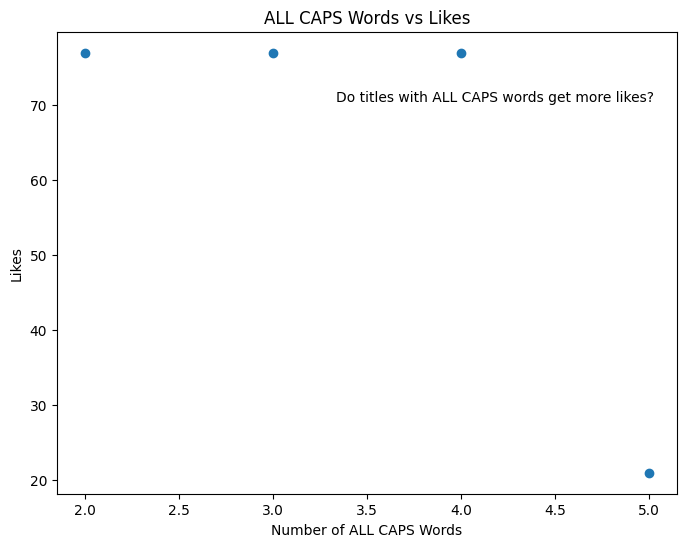

In [20]:
# Apply function to video titles
df["all_caps_words"] = df["title"].apply(count_all_caps_words)

# Create scatter plot
plt.figure(figsize=(8,6))
plt.scatter(df["all_caps_words"], df["likes"])

# Titles and labels
plt.title("ALL CAPS Words vs Likes")
plt.xlabel("Number of ALL CAPS Words")
plt.ylabel("Likes")

# Annotation
plt.annotate(
    "Do titles with ALL CAPS words get more likes?",
    xy=(0.45, 0.85),
    xycoords='axes fraction'
)

# Show chart
plt.show()

##### Interpretation:
###### Most points are aligned horizontally at the 77 average likes, but no other discernable pattern (direction or clustering) exists between the number of all caps words in a video's title and number of likes it receives. In other words, an increase/decrease in the number of all caps words in a video's title does not directly influence the number of likes it receives.

##### Business Impact:
###### Reserved for larger dataset.

### Hashtag vs Engagement
#### Purpose: To see relationship between hashtags and likes (More hashtags = more likes?)

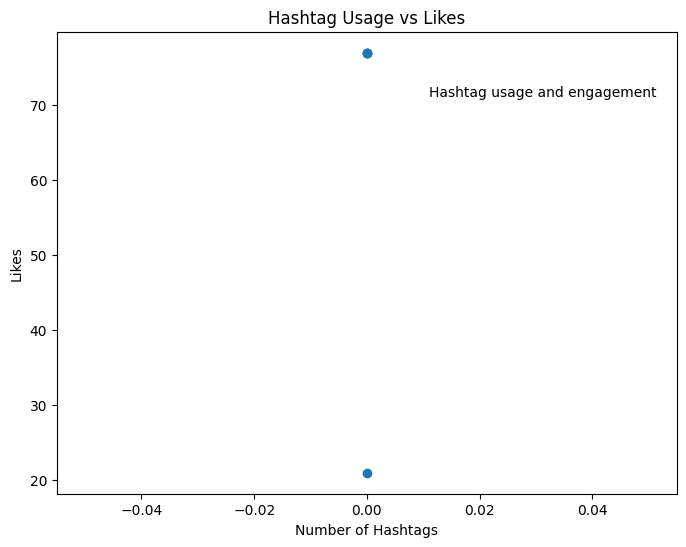

In [21]:
# Function to count hashtags in titles
def count_hashtags(title):
    return len(re.findall(r"#\w+", title)) 

df["hashtag_count"] = df["title"].apply(count_hashtags) # apply function to all titles & stores to column "hastag_count"

plt.figure(figsize=(8, 6))
plt.scatter(df["hashtag_count"], df["likes"]) # scatterplot of no. of hashtags & likes
plt.xlabel("Number of Hashtags")
plt.ylabel("Likes")
plt.title("Hashtag Usage vs Likes")
plt.annotate(
    "Hashtag usage and engagement",
    xy=(0.6, 0.86),
    xycoords='axes fraction'
)
plt.show()

##### Interpretation:
###### The points are aligned vertically above 0 on the x-axis, implying none of the video titles had hashtags. Therefore, a relationship between the number of hashtags in a video's title and number of likes a video receives can be discerned. In other words, an increase/decrease in the number of hashtags in a video's title does not directly influence the number of likes it receives.

##### Business Impact:
###### Reserved for larger dataset.

### Video Length vs Engagement
#### Purpose: To see relationship between video length and likes (Longer video = more likes?)

In [22]:
# Function to Parse Video Duration
def convert_duration(duration):

    # Extract hours
    hours = re.search(r'(\d+)H', duration)

    # Extract minutes
    minutes = re.search(r'(\d+)M', duration)

    # Extract seconds
    seconds = re.search(r'(\d+)S', duration)

    # Convert missing values to 0
    hours = int(hours.group(1)) if hours else 0
    minutes = int(minutes.group(1)) if minutes else 0
    seconds = int(seconds.group(1)) if seconds else 0

    # Convert everything to total seconds
    total_seconds = (
        hours * 3600 +
        minutes * 60 +
        seconds
    )

    return total_seconds

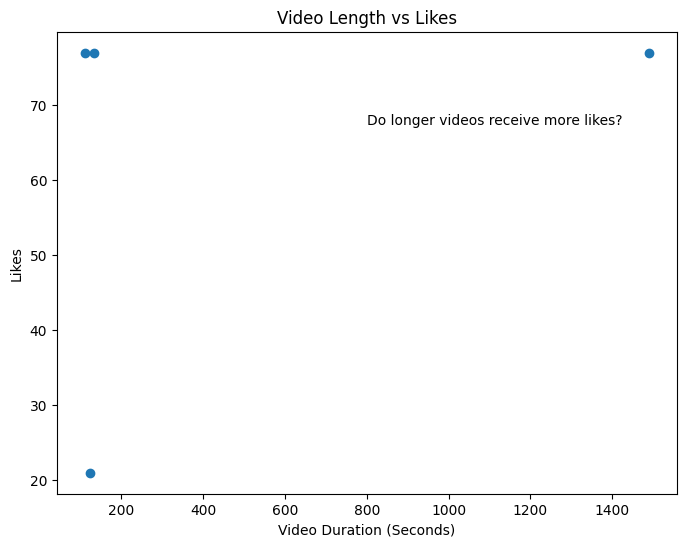

In [23]:
# Apply function to video durations
df["duration_seconds"] = df["duration"].apply(convert_duration) 

# Create scatter plot
plt.figure(figsize=(8,6))
plt.scatter(df["duration_seconds"], df["likes"])

# Titles and labels
plt.title("Video Length vs Likes")
plt.xlabel("Video Duration (Seconds)")
plt.ylabel("Likes")

# Annotation
plt.annotate(
    "Do longer videos receive more likes?",
    xy=(0.5, 0.8),
    xycoords='axes fraction'
)

# Show chart
plt.show()

##### Interpretation:
###### As the points are scattered with no discernable pattern (direction or clustering), no relationship exists between each video's length and number of likes it receives. In other words, neither short nor long videos receive a lesser/greater number of likes.

##### Business Impact:
###### Reserved for larger dataset.

### Sentiment Analysis
#### Purpose: To compare no. of videos with positive and negative sentiment

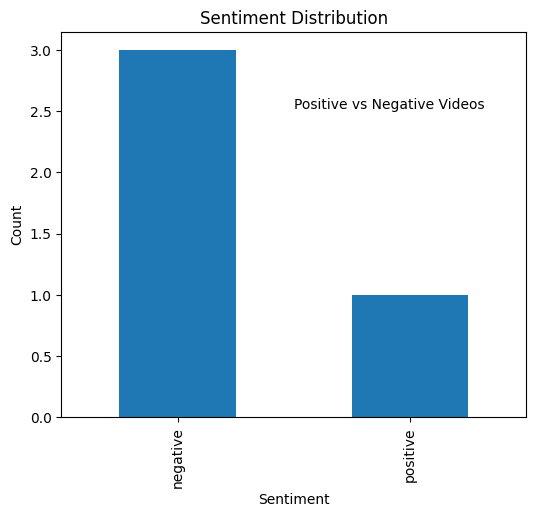

In [24]:
# Function to determine video title sentiment (positive/neutral/negative)
def get_sentiment(title): 
    return TextBlob(title).sentiment.polarity # returns polarity score: ~ +1 (positive), ~ -1 (negative), ~ 0 (neutral)

df["sentiment"] = df["title"].apply(get_sentiment) # applies function to each comment & stores score to column "sentiment"

# applies labels based on score & stores to column "sentiment_label"
df["sentiment_label"] = df["sentiment"].apply(lambda x: "positive" if x > 0 else "negative") 

plt.figure(figsize=(6,5))
df["sentiment_label"].value_counts().plot(kind="bar") # counts sentiment type + plots bar chart accordingly
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Distribution")
plt.annotate(
    "Positive vs Negative Videos",
    xy=(0.5, 0.8),
    xycoords='axes fraction'
)
plt.show()

##### Interpretation:
###### An analysis of the sentiment of the videos' titles revealed that most (3 of 4) where negative, while the least (1 of 4) was positive. It may then be inferred that videos classified as "latest news" are often of negative sentiment as they convey uncheerful news.

##### Business Impact:
###### Reserved for larger dataset.

### Topic Modeling (LDA)/Clustering
#### Purpose: To find common topics in video titles automatically (like unsupervised learning)

In [25]:
# Converts video titles into numbers
vectorizer = CountVectorizer(stop_words="english")
X = vectorizer.fit_transform(df["title"])

# Creates topic model
lda = LatentDirichletAllocation(n_components=3, random_state=42) # Sets topic model to find word groups frequently occurring together i.e. topics (3 topics)
lda.fit(X) # Train model

# Display Topics
print("Top Topics:")
for i, topic in enumerate(lda.components_): # Display topics
    print(f"\nTopic {i+1}:")
    print([vectorizer.get_feature_names_out()[j] for j in topic.argsort()[-10:]]) # Display 10 most important words per topic

Top Topics:

Topic 1:
['mafia', 'flippa', 'dies', 'dennis', 'stabbed', 'surveillance', 'minute', 'gleaner', 'coma', '13']

Topic 2:
['reports', 'deadline', 'cameras', 'calls', 'tabling', 'body', 'legal', 'worn', 'minute', 'gleaner']

Topic 3:
['outrage', 'police', 'james', 'grows', 'seeks', 'st', 'evidence', 'indecom', 'killing', 'video']


##### Interpretation:
###### Three topics like clusters were identified, with their related words. These words were grouped based on their frequency of occurence in the 
###### videos' titles.

##### Business Impact:
###### Reserved for larger dataset.

### Top-Performing Videos
#### Purpose: To display top 10 most liked videos in a horizontal bar chart

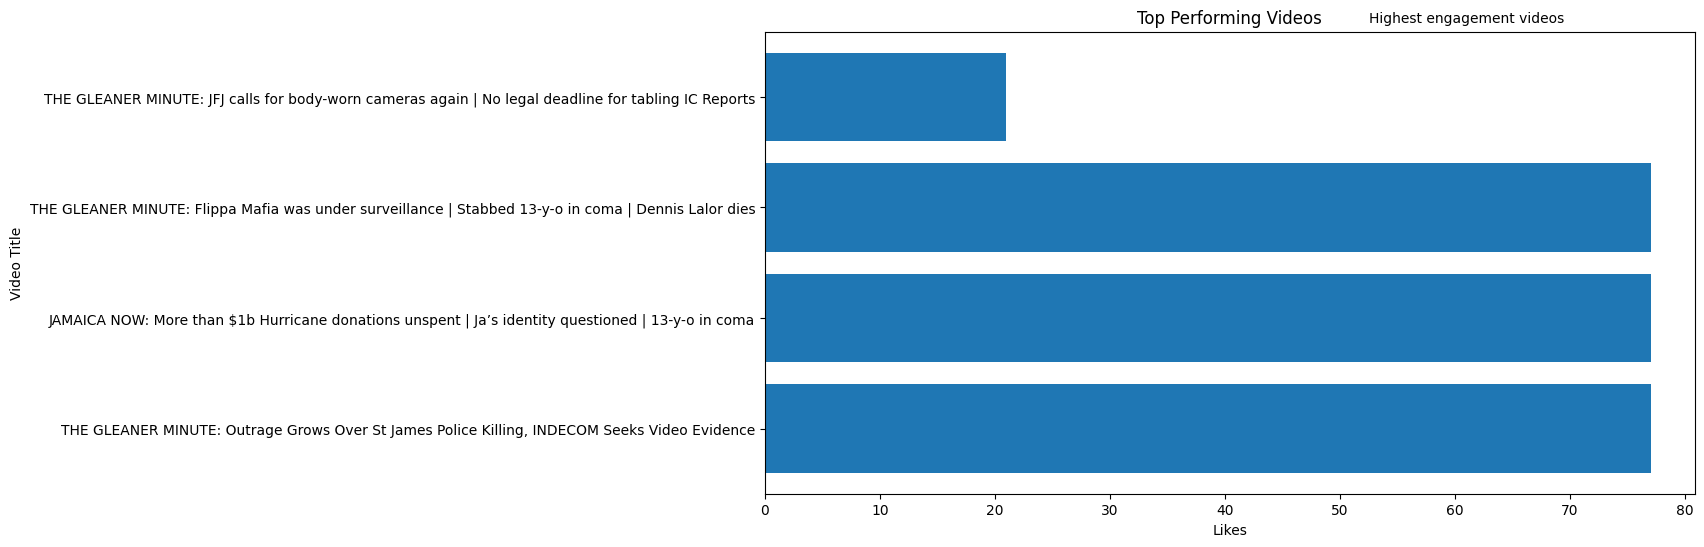

In [26]:
top_videos = df.sort_values(by="likes", ascending=False).head(10) # Displays 10 most liked videos

plt.figure(figsize=(12, 6))
plt.barh(top_videos["title"], top_videos["likes"]) # Create horizontal bar chart comparing titles by likes
plt.xlabel("Likes")
plt.ylabel("Video Title")
plt.title("Top Performing Videos")
plt.annotate(
    "Highest engagement videos",
    xy=(0.65, 1.02),
    xycoords='axes fraction',
)
plt.show()

##### Interpretation:
###### Three videos had similar number of likes. "THE GLEANER MINUTE: Flippa Mafia was under surveillance | Stabbed 13-y-o in coma | Dennis Lalor dies", "JAMAICA NOW: More than $1b Hurricane donations unspent | Ja's identity questioned | 13-y-o in coma" and "THE GLEANER MINUTE: Outrage Grows Over St James Police Killing, INDECOM Seeks Video Evidence" had the highest engagement (likes) levels at 77.

##### Business Impact:
###### Reserved for larger dataset.